# Uso avanzado de redes neuronales recurrentes

En esta seccion se presentan tres tecnicas para mejorar el rendimiento y poder de generalizacion de las redes neuronales recurrentes:
- ***Recurrent dropout***: aplicacion recurrente de dropout para pelear con el *overfitting*.
- ***Stacking recurrent layers***: mejora el poder de representacion a costa de mas carga computacional.
- ***Bidirectional recurrent layers***: presentan la misma informacion que las redes recurrentes pero de otra forma. Mejoran el *accuracy* y mitigan problemas de olvido.

Estos problemas se exploran en un problema donde en base a series de informacion ambiental hay que predecir la temperatura de las proximas 24hs.

# Problema de prediccion de temperatura

Conjunto de datos capturados en la *Estacion del Clima del Instituto Max Planck para Biogeoquimica en Jena, Alemania*. 

El conjunto de datos posee datos capturados **cada 10 minutos** de **14 metricas** distintas (temperatura, presion atmosferica, humedad, etc). El conjunto de datos original empieza en 2003 pero en esta seccion se usan datos de 2009-2016.

A continuacion se muestra como descargar el conjunto de datos:

In [1]:
# !mkdir datasets/jena_climate
# !wget -P datasets/ https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
# !unzip datasets/jena_climate_2009_2016.csv.zip -d datasets/jena_climate

A continuacion se muestra como cargarlo en el entorno:

In [1]:
import os

data_dir = 'datasets/jena_climate'
fname = os.path.join(data_dir, 'jena_climate_2009_2016.csv')

f = open(fname)
data = f.read()
f.close()

lines = data.split('\n')
header = lines[0].split(',')
lines = lines[1:]

print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


Lo mejor es convertir las 420451 lineas de datos en un arreglo numpy:

In [2]:
import numpy as np

float_data = np.zeros((len(lines), len(header)-1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(',')[1:]]    # Se elimina la columna 'Date Time'
    float_data[i,:] = values

No es necesario guardar la columna *Date Time* ya que la informacion de secuencia temporal esta implicita por la posicion de los datos.

A continuacion se muestra la temperatura en celsius del dataset:

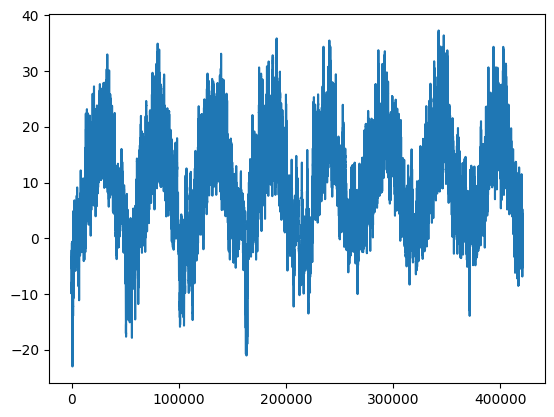

In [4]:
from matplotlib import pyplot as plt

temp = float_data[:, 1] 
plt.plot(range(len(temp)), temp)

La periodicidad anual es evidente, tambien hay que recordar que los datos se capturan cada 10 minutos por lo que el dataset contine 144 entradas por dia.

A continuacion se muestra la entrada de los primeros 10 dias:

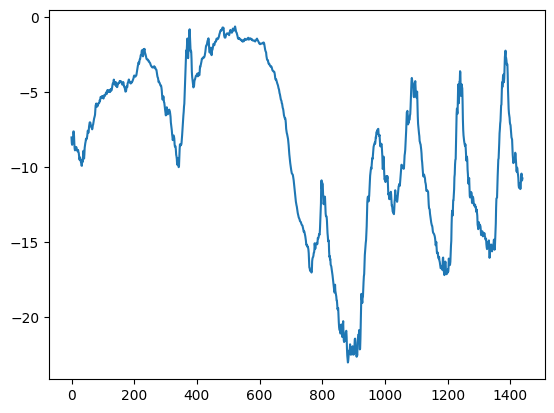

In [33]:
from matplotlib import pyplot as plt

timesteps = 144 * 10
plt.plot(range(timesteps), temp[:timesteps])

La periodicidad diaria es particularmente evidente en los ultimos 4 dias pero no para los demas. 

Los datos corresponden a un invierno particularmente frio.

El problema es **sencillo a nivel anual**, pero el comportamiento a nivel **diario es mas caotico**.

# Preparando los datos

Se va a entrenar un modelo que recibe **informacion de variables ambiendales de los ultimos 5 dias** y en base a eso **predicir temperatura 24 horas adelante**.

El muestreo sera de **un registro por hora (6:1)**

Para el entrenamiento se usaran las primeras 200000 entradas (3.8 años).

Cada atributo del dataset maneja sus propios rangos por lo que se empieza aplicando una normalizacion sobre el conjunto de datos de entrenamiento.

In [3]:
mean = float_data[:200000].mean(axis=0)
float_data -= mean
std = float_data[:200000].std(axis=0)
float_data /= std

Los lapsos de 5 dias que se usaran como entradas tienen mucha redundancia entre si. Para evitar ineficiencias de memoria se arma una funcion generador que el modelo ira llamando durante su entrenamiento para obtener bajo demanda los conjuntos de datos de cada lote. 

In [4]:
"""_sumary_
Params:
- data: conjunto de datos.
- lookback: cuantos timesteps atras hay que considerar.
- delay: cuantos timesteps a futuro esta el objetivo.
- min_index: limite inferior de los datos a considerar.
- max_index: limite superior de los datos a considerar.
- shuffle: proveer datos en orden cronologico o no.
- batch_size: tamaño de lote.
- step: cada cuantos timeteps devolver informacion.
"""
from keras.utils import Sequence
import numpy as np
import math

class JenaClimateSequence(Sequence):

  def __init__(self, data, lookback, delay, min_index, max_index,
                 batch_size=128, step=6, shuffle=False):
    self.data = data
    self.lookback = lookback
    self.delay = delay
    self.min_index = min_index
    self.max_index = max_index if max_index is not None else len(data) - delay - 1
    self.batch_size = batch_size
    self.step = step
    self.shuffle = shuffle
    self.indices = np.arange(self.min_index, self.max_index)
    self.i = min_index + lookback

  # Number of batch in the Sequence.
  def __len__(self):
    #return math.ceil((self.max_index - (self.min_index + self.lookback)) / self.batch_size)
    return 500

  # Gets batch at position index
  def __getitem__(self, idx):
    if self.shuffle:
      rows = np.random.randint(
        self.min_index + self.lookback, self.max_index, size=self.batch_size
      )
    else:
      if self.i + self.batch_size + self.delay >= self.max_index:
        #print("⚠️ Reiniciar:", i, min_index, max_index)
        self.i = self.min_index + self.lookback
      rows = np.arange(self.i, min(self.i+self.batch_size, self.max_index - self.delay))
      self.i += len(rows)

    samples = np.zeros((len(rows), self.lookback // self.step, self.data.shape[-1]))
    targets = np.zeros((len(rows),))
    for j, row in enumerate(rows):
      indices = range(row - self.lookback, row, self.step)
      samples[j] = self.data[indices]
      targets[j] = self.data[row + self.delay][1]

    return samples, targets

2026-01-06 21:18:51.295976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767745131.313098 2111906 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767745131.318340 2111906 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767745131.332344 2111906 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767745131.332363 2111906 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767745131.332365 2111906 computation_placer.cc:177] computation placer alr

Se preparan generadores con 200000 registros para *train*, 100000 para *val* y los demas para *test* (≈120000).

In [5]:
lookback = 1440     # 5 dias
step = 6            # 1 x hora
delay = 144         # 24hs adelante
batch_size = 128

train_gen = JenaClimateSequence(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=0,
    max_index=200000,
    shuffle=True,
    step=step,
    batch_size=batch_size
)

val_gen = JenaClimateSequence(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=200001,
    max_index=300000,
    step=step,
    batch_size=batch_size
)

test_gen = JenaClimateSequence(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=300001,
    max_index=None,
    step=step,
    batch_size=batch_size
)

# timesteps considerados dentro de val
val_steps = (300000 - 200001 - lookback) 

# timesteps considerados dentro de test
test_steps = (len(float_data) - 300001 - lookback)

print(f"val_steps {val_steps}, test_steps {test_steps}")

val_steps 98559, test_steps 119010


# Linea base 

Como aproximacion ingenua se usa un modelo que siempre predice que la temperaturatura dentro de 24hs sera excactamente igual a la temperatura del instante donde esto se esta leyendo. Como linea base tiene sentido ya que el clima tiene cierta periodicidad (el clima de mañana probablemente sea parecido al de hoy).

Para obtener la linea base se usa MAE (Mean Absolute Error):
```
np.mean(np.abs(preds - targets))
```

A continuacion se define la funcion responsable de hacer la cuenta.

In [ ]:
def evalue_naive_method():
    batch_maes = []
    for step in range(val_steps):
        samples, targets = val_gen[step]
        preds = samples[:, -1, 1]
        mae = np.mean(np.abs(preds - targets))
        batch_maes.append(mae)
    print(np.mean(batch_maes))

evalue_naive_method()


Esta aproximacion reporta un MAE de 0.29. 

Ya que el conjunto de datos fue normalizado (media 0 y desviacion 1) la metrica no es directamente interpretable pero se puede hallar el valor Celcius multiplicando con el valor de desviacion que corresponde al atributo.

In [ ]:
celcius_mae = 0.29 * std[1]
print(f"{celcius_mae:.2f}°C")

2.57°C


# Modelo básico

Es útil aplicar una aproximación *machine learning* sencilla ya que da un punto de comparación para cualquier modificación que se aplique después.

Se aplica una secuencia de aplanado para hacer digeribles los datos, una capa densa con activación y una densa mas sin activación para reportar el valor de salida.

In [ ]:
from keras.models import Sequential
from keras.layers import Flatten, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(Flatten(input_shape=(lookback // step, float_data.shape[-1])))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(
    train_gen,
    #steps_per_epoch=500,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps)

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1764430926.958564  504878 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11534 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1


Epoch 1/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1764430928.143559  505226 service.cc:152] XLA service 0x7f4410001f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764430928.143591  505226 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-11-29 12:42:08.160302: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1764430928.216615  505226 cuda_dnn.cc:529] Loaded cuDNN version 90300


 27/500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.4251

I0000 00:00:1764430928.521933  505226 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 2.1875 - val_loss: 1.0590
Epoch 2/20
 27/500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.9536

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.7982 - val_loss: 0.3119
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.3460 - val_loss: 0.2964
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2732 - val_loss: 0.3344
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2593 - val_loss: 0.3156
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2503 - val_loss: 0.3127
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2402 - val_loss: 0.3222
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2359 - val_loss: 0.3058
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2282 - val_loss: 0.3340
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2264 - val_loss: 0.3410
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2220 - val_loss: 0.3110
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2198 - val_loss: 0.3396
Epoch 13/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/st

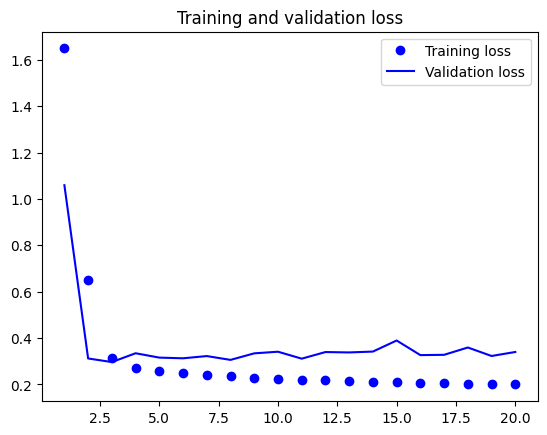

In [ ]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

El rendimiento del modelo en su mejor momento fue 0.31. Peor que la linea de base sin ML por 0.02. 

    *"El sentido comun contiene un monton de informacion valiosa a la que modelos de ML no tienen acceso"*.

En este caso el sentido comun va dado por repetir el valor de 24 hs antes. No es algo tan dificil de modelar para el modelo ya que seria solo activar la ultima neurona para el calculo del valor final. Aun asi, **puede ser dificil de hallar en el amplio espacio de soluciones del modelo**.

El modelo no es conciente del orden de los datos, le da la misma importancia a todos los elementos independientemente de la distancia con el valor a predecir.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3360)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       107,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,172 (840.52 KB)

 Trainable params: 107,585 (420.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 107,587 (420.27 KB)

# Modelo recurrente

La aproximacion recurrente puede explotar el ordenamiento temporal de los datos.

Se van a utilizar 32 capas GRU (LSTM mas ligera pero con menos poder de representación). Y una capa densa al final para la regresion final.

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(32, input_shape=(None, float_data.shape[-1])))
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(
    train_gen,
    #steps_per_epoch=500,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps)

Epoch 1/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.3269 - val_loss: 0.2828
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2855 - val_loss: 0.2606
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2786 - val_loss: 0.2648
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2733 - val_loss: 0.2700
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2662 - val_loss: 0.2556
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2628 - val_loss: 0.2537
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2577 - val_loss: 0.2773
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2525 - val_loss: 0.2543
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2481 - val_loss: 0.2615
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2431 - val_loss: 0.2829
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2394 - val_loss: 0.2531
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/ste

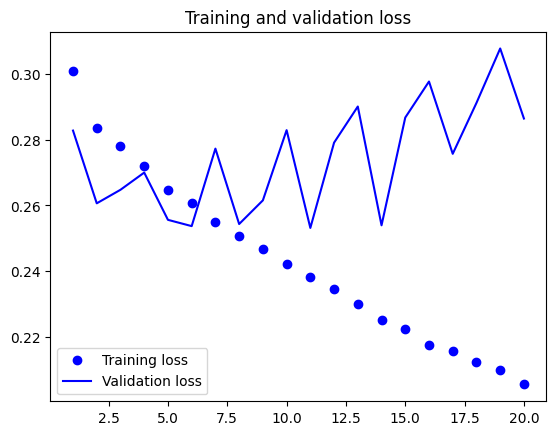

In [ ]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

La aproximacion recurrente logro mejorar el MAE a 0.26. Mejor que la linea base pero tambien muestra un *overfitting* mas pronunciado. 

Puede considerarse una buena señal que halla *overfitting*. **Que** el modelo **memorice patrones** del conjunto de train **indica que es capaz de aprender** de los datos que recibe.

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,284 (36.27 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,643 (18.14 KB)

La version recurrente **pesa el 4% de** lo que pesa la **version *Dense***. 

Tambien, es **40% mas lenta** que su antecesor. La ingesta es secuencial, lo que ejecucion de operaciones paralelas durante el entrenamiento de la red.

In [ ]:
celcius_mae = 0.26 * std[1]
print(f"{celcius_mae:.2f}°C")

2.30°C


El error de prediccion es de 2.30°C. Una ganancia solida respecto al 2.57°C anterior.

# Dropout para evitar el *overfitting*

Para aplicar correctamente *dropout* en una capa recurrente es importante aplicar la misma mascara de anulacion en cada iteracion de la red.

Aplicar dropout antes de la capa recurrente y/o en cada iteracion pero con mascaras independientes perjudica el aprendizaje mas de lo que ayuda a la regularizacion.

En ``keras`` las redes recurrentes incorporan una version adaptada del dropout configurable mediante el parametro de igual nombre.

In [12]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    32, 
    dropout=0.2, 
    recurrent_dropout=0.2, 
    input_shape=(None, float_data.shape[-1]))
)
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(
    train_gen, 
    epochs=40,
    validation_data=val_gen,
    validation_steps=val_steps)

Epoch 1/40


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 182s 360ms/step - loss: 0.3723 - val_loss: 0.2892
Epoch 2/40


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 174s 348ms/step - loss: 0.3137 - val_loss: 0.2612
Epoch 3/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 167s 335ms/step - loss: 0.3085 - val_loss: 0.2670
Epoch 4/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 200s 332ms/step - loss: 0.3034 - val_loss: 0.2901
Epoch 5/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 335ms/step - loss: 0.2991 - val_loss: 0.2611
Epoch 6/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 167s 335ms/step - loss: 0.2941 - val_loss: 0.2653
Epoch 7/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 166s 332ms/step - loss: 0.2935 - val_loss: 0.2702
Epoch 8/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 167s 333ms/step - loss: 0.2896 - val_loss: 0.2557
Epoch 9/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 166s 333ms/step - loss: 0.2875 - val_loss: 0.2778
Epoch 10/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 335ms/step - loss: 0.2879 - val_loss: 0.2695
Epoch 11/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 335ms/step - loss: 0.2870 - val_loss: 0.2577
Epoch 12/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 167s 335ms/step - loss: 0.2851 - val_loss: 0.2665
Epoch 13/40
500/50

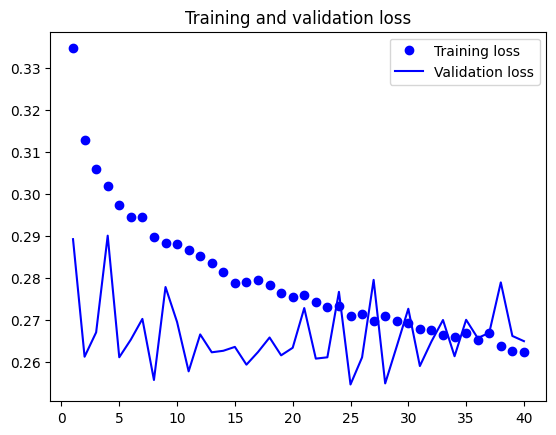

In [15]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

La metrica de validacion en este caso fue mejer el mejor rendimiento (MAE 0.26) es apenas peor al caso anterior pero los resultados son mas estables y el *overfitting* es menos pronunciado.

El entrenamiento es un **2,600% mas lento**. Al usarlo *recurrent_dropout* Tensorflow pasa de uasr la version *cuDNN* optimizada de GRU a la implementacion estandar de GRU. Esta version carece de muchas optimizaciones y provoca que la ejecucion sea mucho mas lenta ([documentacion oficial](https://keras.io/api/layers/recurrent_layers/gru/)).

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,284 (36.27 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,643 (18.14 KB)

# Apilar capas recurrentes

El modelo ya no sobre ajusta pero encontro un cuello de botella en el rendimiento. Se ve incapas de reducir el error a partir de cierto umbral.

Para enfrentarlo se **incrementa la capacidad**. En redes recurrentes la forma tipica de lograrlo es el apilado de capas recurrentes.

Es importante que cada capa recurrente intermedia retorne la secuencia completa de outputs en vez de sola el ultimo resultado.

In [17]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    32,
    dropout=0.1,
    recurrent_dropout=0.5,
    return_sequences=True,
    input_shape=(None, float_data.shape[-1])
))
model.add(GRU(
    64, 
    activation='relu',
    dropout=0.1,
    recurrent_dropout=0.5,
))

model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')

history = model.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    validation_steps=val_steps
)

Epoch 1/40


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 374s 741ms/step - loss: 0.3612 - val_loss: 0.2804
Epoch 2/40


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 369s 739ms/step - loss: 0.3139 - val_loss: 0.2687
Epoch 3/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 369s 739ms/step - loss: 0.3087 - val_loss: 0.2715
Epoch 4/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 370s 740ms/step - loss: 0.3020 - val_loss: 0.2897
Epoch 5/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 382s 740ms/step - loss: 0.2976 - val_loss: 0.2612
Epoch 6/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 369s 739ms/step - loss: 0.2950 - val_loss: 0.2616
Epoch 7/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 370s 741ms/step - loss: 0.2926 - val_loss: 0.2786
Epoch 8/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 370s 740ms/step - loss: 0.2896 - val_loss: 0.2645
Epoch 9/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 370s 741ms/step - loss: 0.2873 - val_loss: 0.2641
Epoch 10/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 371s 742ms/step - loss: 0.2860 - val_loss: 0.2695
Epoch 11/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 370s 741ms/step - loss: 0.2849 - val_loss: 0.2563
Epoch 12/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 371s 742ms/step - loss: 0.2808 - val_loss: 0.2734
Epoch 13/40
500/50

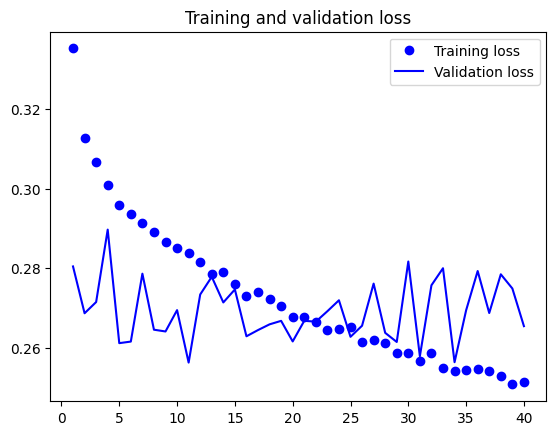

In [18]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

La **mejora** es **pequeña**. 

Se puede concluir:
- Como el *overfitting* no es pronunciado se puede incrementar el tamaño de cada capa para reducir el error. Implica mas coste computacional.
- La mejora de agregar una capa no fue significativa, incrementar mas la capacidad mostrara rendimientos decrecientes a partir de este punto.

# Redes recurrentes bidireccionales

Es frecuentemente usada en tareas de Procesamiento de Lenguaje Natural (PLN). Las palabras de una frase cambian de significado no solo por las palabras anteriores a estas sino a tambien por las palabras que le siguen. El analisis bidireccional favorece el analisis contextual de las palabras.

Consiste en la union de 2 RNN regulares, cada cual procesa el *input* en una direccion y luego combinan sus representaciones. Pueden atrapar patrones que una RNN direccional podria pasar por alto.

## ¿Un RNN que reciba los datos en el orden inverso tendra un rendimiento competente?

Se puede comprobar escribiendo una variante del generador de datos y reentrenando el modelo GRU de una capa.

In [21]:
"""_sumary_
Params:
- data: conjunto de datos.
- lookback: cuantos timesteps atras hay que considerar.
- delay: cuantos timesteps a futuro esta el objetivo.
- min_index: limite inferior de los datos a considerar.
- max_index: limite superior de los datos a considerar.
- shuffle: proveer datos en orden cronologico o no.
- batch_size: tamaño de lote.
- step: cada cuantos timeteps devolver informacion.
"""
from keras.utils import Sequence
import numpy as np
import math

class JenaClimateSequenceInverted(Sequence):

  def __init__(self, data, lookback, delay, min_index, max_index,
                 batch_size=128, step=6, shuffle=False):
    self.data = data
    self.lookback = lookback
    self.delay = delay
    self.min_index = min_index
    self.max_index = max_index if max_index is not None else len(data) - delay - 1
    self.batch_size = batch_size
    self.step = step
    self.shuffle = shuffle
    self.indices = np.arange(self.min_index, self.max_index)
    self.i = min_index + lookback

  # Number of batch in the Sequence.
  def __len__(self):
    #return math.ceil((self.max_index - (self.min_index + self.lookback)) / self.batch_size)
    return 500

  # Gets batch at position index
  def __getitem__(self, idx):
    if self.shuffle:
      rows = np.random.randint(
        self.min_index + self.lookback, self.max_index, size=self.batch_size
      )
    else:
      if self.i + self.batch_size + self.delay >= self.max_index:
        #print("⚠️ Reiniciar:", i, min_index, max_index)
        self.i = self.min_index + self.lookback
      rows = np.arange(self.i, min(self.i+self.batch_size, self.max_index - self.delay))
      self.i += len(rows)

    samples = np.zeros((len(rows), self.lookback // self.step, self.data.shape[-1]))
    targets = np.zeros((len(rows),))
    for j, row in enumerate(rows):
      indices = range(row - self.lookback, row, self.step)
      samples[j] = self.data[indices]
      targets[j] = self.data[row + self.delay][1]

    return samples[:, ::-1, :], targets

In [22]:
lookback = 1440     # 5 dias
step = 6            # 1 x hora
delay = 144         # 24hs adelante
batch_size = 128

train_gen = JenaClimateSequenceInverted(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=0,
    max_index=200000,
    shuffle=True,
    step=step,
    batch_size=batch_size
)

val_gen = JenaClimateSequenceInverted(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=200001,
    max_index=300000,
    step=step,
    batch_size=batch_size
)

test_gen = JenaClimateSequenceInverted(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=300001,
    max_index=None,
    step=step,
    batch_size=batch_size
)

# timesteps considerados dentro de val
val_steps = (300000 - 200001 - lookback) 

# timesteps considerados dentro de test
test_steps = (len(float_data) - 300001 - lookback)

print(f"val_steps {val_steps}, test_steps {test_steps}")

val_steps 98559, test_steps 119010


In [9]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    32, 
    dropout=0.2, 
    recurrent_dropout=0.2, 
    input_shape=(None, float_data.shape[-1]))
)
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(
    train_gen, 
    epochs=40,
    validation_data=val_gen,
    validation_steps=val_steps)

I0000 00:00:1765147917.728230 3201825 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11534 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1
/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 329ms/step - loss: 0.5266 - val_loss: 0.4892
Epoch 2/40


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 163s 326ms/step - loss: 0.4806 - val_loss: 0.4978
Epoch 3/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 163s 326ms/step - loss: 0.4611 - val_loss: 0.3749
Epoch 4/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 163s 326ms/step - loss: 0.3592 - val_loss: 0.2820
Epoch 5/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 163s 326ms/step - loss: 0.3132 - val_loss: 0.2782
Epoch 6/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 163s 325ms/step - loss: 0.3070 - val_loss: 0.2888
Epoch 7/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 325ms/step - loss: 0.2987 - val_loss: 0.2711
Epoch 8/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 161s 322ms/step - loss: 0.2995 - val_loss: 0.2772
Epoch 9/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 325ms/step - loss: 0.2972 - val_loss: 0.2846
Epoch 10/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 324ms/step - loss: 0.2926 - val_loss: 0.2742
Epoch 11/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 323ms/step - loss: 0.2932 - val_loss: 0.2821
Epoch 12/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 324ms/step - loss: 0.2893 - val_loss: 0.2833
Epoch 13/40
500/50

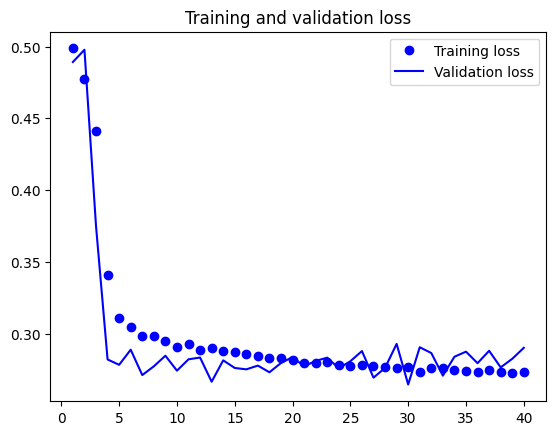

In [10]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

El mejor MAE en validacion es 0.28. Peor que ingresando los datos de mas antiguo a mas nuevo (0.26). Apenas mejor que la linea base ingenua (0.29).

El ingreso cronologico de los datos es relevante para este modelo, lo cual tiene sentido ya que las capas GRU son mejores para recordar el pasado reciente que el distante. Al pasarle primero los mas recientes estos son diluidos a medida que ingresan datos antiguos. Termina olvidando los datos mas recientes cuando estos son los que tienen mas poder predictivo para predecir el clima.

En este problema es mejor recordar los datos mas cercanos pero eso no siempre es asi. En PLN las palabras mas importantes no siempre son las mas cercanas. La importancia de una palabra para entender una oracion no suele estar ligada a su posicion.

## IMDb para sequencias inversas

INvertir la entrada en una red LSTM con datos de IMDb.

In [1]:
from keras.datasets import imdb
from keras.preprocessing import sequence

max_features = 1000 # Palabras a considerar en el diccionario
max_len = 500       # Truncar en esa cantidad de palabras

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Revertir secuencias
x_train = [x[::-1] for x in x_train]
x_test = [x[::-1] for x in x_test]

x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)

2025-12-07 22:21:32.858939: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765156892.876573 3250590 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765156892.881908 3250590 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765156892.895849 3250590 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765156892.895867 3250590 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765156892.895869 3250590 computation_placer.cc:177] computation placer alr

In [4]:
from keras.layers import LSTM, Embedding, Dense
from keras.models import Sequential

emb_size = 128   # Tamaño del vector embedding

model = Sequential()
model.add(Embedding(max_features, emb_size))
model.add(LSTM(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(
    x_train, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10


I0000 00:00:1765156929.233486 3250590 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11534 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1
I0000 00:00:1765156931.146993 3250885 cuda_dnn.cc:529] Loaded cuDNN version 90300


157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - acc: 0.5478 - loss: 0.6807 - val_acc: 0.7144 - val_loss: 0.5766
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc: 0.7031 - loss: 0.5857 - val_acc: 0.7930 - val_loss: 0.4764
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - acc: 0.7775 - loss: 0.4982 - val_acc: 0.8030 - val_loss: 0.4576
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc: 0.7985 - loss: 0.4662 - val_acc: 0.7698 - val_loss: 0.5132
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.7937 - loss: 0.4633 - val_acc: 0.7816 - val_loss: 0.4818
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - acc: 0.8179 - loss: 0.4310 - val_acc: 0.8376 - val_loss: 0.4015
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - acc: 0.8374 - loss: 0.3925 - val_acc: 0.8492 - val_loss: 0.4180
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - acc: 0.8524 - loss: 0.3738 - val_acc: 0.8430 - val_loss: 0.3770
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc:

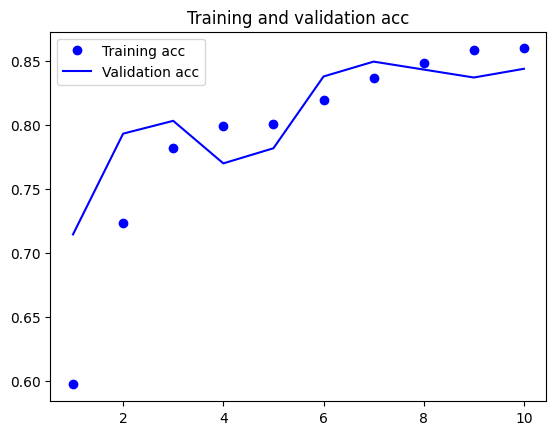

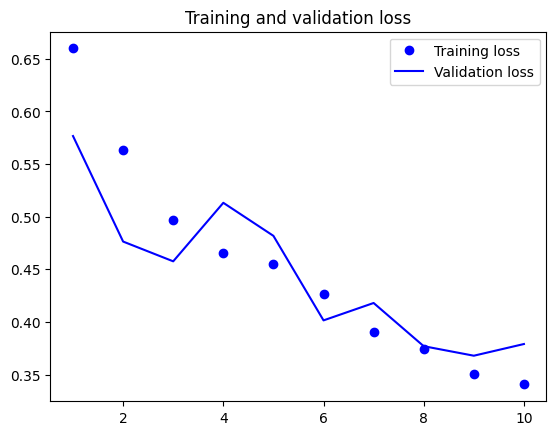

In [6]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation acc')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Para **procesamiento de texto** el orden reverso es tan bueno como el orden regular. En estos casos el que **orden usar no es crucial**. Contrastar contra la ultima seccion de [6.2.3.lstm-in-IMDb.ipynb](/6.2.3.lstm-in-IMDb.ipynb).

No obstante, distintos ordenes permiten aprender diferentes representaciones, representaciones que ven aspectos que otras pierden y pueden ayudar a mejorar el rendimiento de una tarea.

## BRNN para IMDb

Las RNN Bidireccionales (BRNN) explotan las representaciones generadas por procesar los datos ordenados e invertidos.

Potencialmne obtienen reprecentacioes mas ricas ya que pueden capturar patrones que se le escapan a aproximaciones que solo usan el orden cronologico. 

![Como funciona una BRNN](images/6.3.0.bidireccional-rnn.png)

In [12]:
from keras.layers import Bidirectional

model = Sequential()
model.add(Embedding(max_features, emb_size))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(
    x_train,y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - acc: 0.5355 - loss: 0.6858 - val_acc: 0.6892 - val_loss: 0.6025
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - acc: 0.6829 - loss: 0.5996 - val_acc: 0.7514 - val_loss: 0.5241
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - acc: 0.7638 - loss: 0.5168 - val_acc: 0.7878 - val_loss: 0.4910
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - acc: 0.7912 - loss: 0.4738 - val_acc: 0.7640 - val_loss: 0.5066
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - acc: 0.8002 - loss: 0.4558 - val_acc: 0.6836 - val_loss: 0.7165
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.8234 - loss: 0.4168 - val_acc: 0.6444 - val_loss: 1.0087
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - acc: 0.8389 - loss: 0.3958 - val_acc: 0.8462 - val_loss: 0.4174
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - acc: 0.8555 - loss: 0.3589 - val_acc: 0.8572 - val_loss: 0.3523
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/

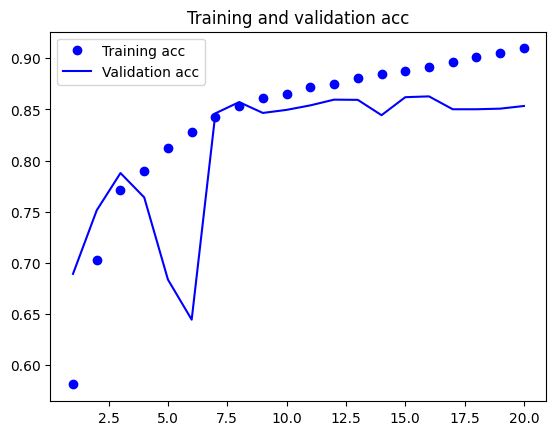

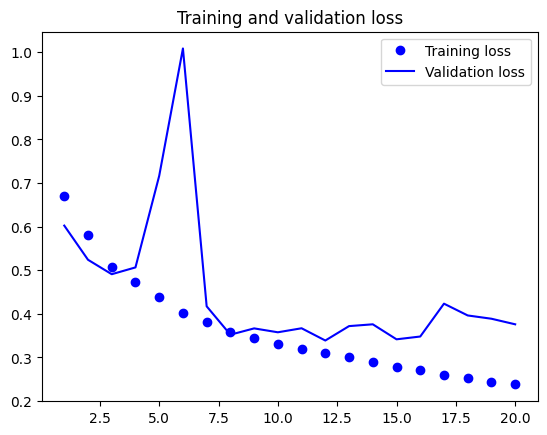

In [14]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation acc')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

El incremento en **tiempo  por epoca** es **x1.6**. 

En la **misma cantidad de epocas** se obtubo un puntaje similar, aunque ahora **levemente por encima** de 85%, antes estaba levemente por debajo.

Al dejarlo **mas epocas** se alcanza una **barrera en 86%**.

## BRNN para prediccion de clima

In [7]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Bidirectional
from keras.optimizers import RMSprop

model = Sequential()
model.add(Bidirectional(GRU(32), input_shape=(None, float_data.shape[-1])))
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(
    train_gen, 
    epochs=40, 
    validation_data=val_gen,
    validation_steps=val_steps)

Epoch 1/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - loss: 0.3060 - val_loss: 0.2830
Epoch 2/40
 10/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.2790

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2772 - val_loss: 0.2801
Epoch 3/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2679 - val_loss: 0.2593
Epoch 4/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2650 - val_loss: 0.2660
Epoch 5/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2597 - val_loss: 0.2793
Epoch 6/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2560 - val_loss: 0.2556
Epoch 7/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2513 - val_loss: 0.2765
Epoch 8/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2440 - val_loss: 0.2822
Epoch 9/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2389 - val_loss: 0.2694
Epoch 10/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2357 - val_loss: 0.2903
Epoch 11/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2292 - val_loss: 0.2890
Epoch 12/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.2244 - val_loss: 0.2922
Epoch 13/40
500/500 ━━━━━━━━━━━━━━━━━━━━

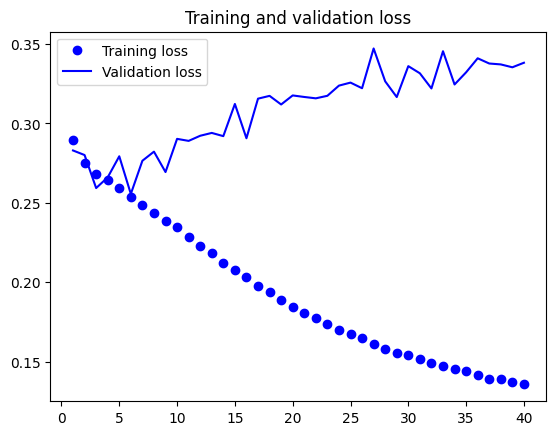

In [9]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

El rendimiento de la red fue **similar a la version cronologica**. 

El ***overfitting*** es muy **pronunciado** pero se puede tratar con regularizacion.

Es probable que la **mayoria del poder predictivo** de la red venga de la **mitad que procesa** los datos en **orden cronologico**, ya que la otra mitad mostro un rendimiento malo para esta tarea (comparable a la linea base). 

Tiene sentido ya que **en este problema** el **pasado reciente es mas relevante que el pasado distante**.

# Otras mejoras

Se pueden aplicar otras estrategias para mejorar el MAE de 0.25 que se obtubo antes.

## Ajustar numero de unidades en GRU apilada

Modificar cantidad de unidades usadas para obtener mejor rendimiento (no se usa dropout ya que alarga mucho el entrenamiento en redes recurrentes).

### 32 y 64

Linea base de 32 y 64

In [11]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    32,
    return_sequences=True,
    input_shape=(None, float_data.shape[-1])
))
model.add(GRU(
    64, 
    activation='relu',
))
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')

history = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    validation_steps=val_steps
)


Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 279ms/step - loss: 0.3280 - val_loss: 0.2696
Epoch 2/15


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2850 - val_loss: 0.2632
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 277ms/step - loss: 0.2736 - val_loss: 0.2727
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2658 - val_loss: 0.2619
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2587 - val_loss: 0.2559
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2529 - val_loss: 0.2739
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 277ms/step - loss: 0.2463 - val_loss: 0.2699
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2389 - val_loss: 0.2739
Epoch 9/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 278ms/step - loss: 0.2281 - val_loss: 0.2914
Epoch 10/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 278ms/step - loss: 0.2232 - val_loss: 0.2786
Epoch 11/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 279ms/step - loss: 0.2136 - val_loss: 0.2940
Epoch 12/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 277ms/step - loss: 0.2042 - val_loss: 0.3086
Epoch 13/15
500/50

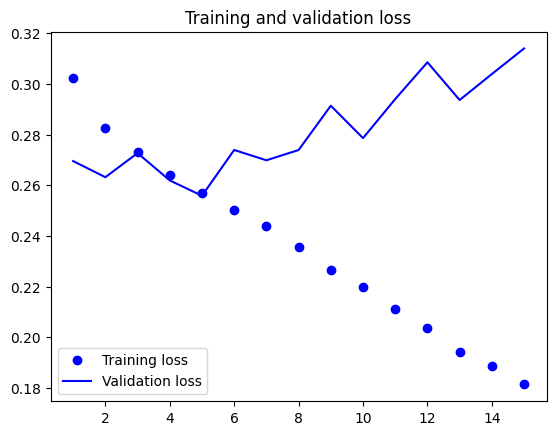

In [12]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

El **MAE** es **0.26**. Mejor que la linea base (0.29)

A partir de la **epooca 6** hay sintomas de ***overfitting***.

### 16 y 32

Se reducen a la mitad las neuronas de cada capa. 

La cantidad inicial de atributos es de 13, la primera capa redimenciona a 16 y la que sigue estira a 32. 

Sirve para determinar si se puede obtener el mismo rendimiento con menos neuronas.

In [13]:
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    16,
    return_sequences=True,
    input_shape=(None, float_data.shape[-1])
))
model.add(GRU(
    32, 
    activation='relu',
))
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')

history = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    validation_steps=val_steps
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 262ms/step - loss: 0.3584 - val_loss: 0.2778
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 260ms/step - loss: 0.2874 - val_loss: 0.2704
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 261ms/step - loss: 0.2770 - val_loss: 0.2560
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 260ms/step - loss: 0.2774 - val_loss: 0.2666
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 258ms/step - loss: 0.2711 - val_loss: 0.2703
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 260ms/step - loss: 0.2691 - val_loss: 0.2604
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 259ms/step - loss: 0.2641 - val_loss: 0.2574
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 260ms/step - loss: 0.2613 - val_loss: 0.2722
Epoch 9/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 259ms/step - loss: 0.2548 - val_loss: 0.2634
Epoch 10/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 259ms/step - loss: 0.2517 - val_loss: 0.2648
Epoch 11/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 260ms/step - loss: 0.2474 - val_loss: 0.2787
Epoch 12

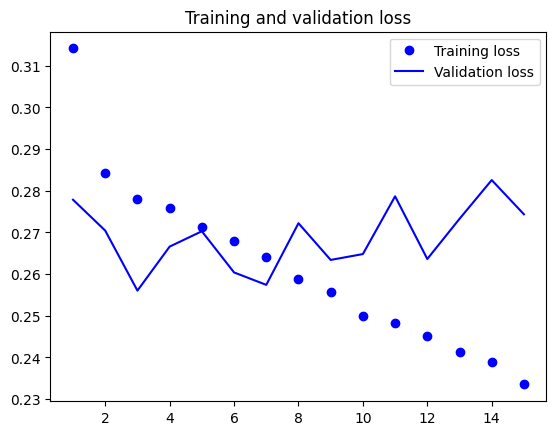

In [14]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Se **mantiene** el **MAE** de **0.26**.  

Hay **menos overfiting** ya que el modelo es menos complejo

El tiempo de entrenamiento por epoch bajo 9 segundos respecto a la version base.

### 8 y 16

Se achica otra vez la primera redimension. Estas ves se reducen los 13 atributos base a 8 y luego se los estira a 16. 

Se espera que el resultado sea peor que en la version anterior ya que se estaria forzando a desechar informacion que no pueda ser recodificada en menos dimensiones.

In [18]:
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    8,
    return_sequences=True,
    input_shape=(None, float_data.shape[-1])
))
model.add(GRU(
    16, 
    activation='relu',
))
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 280ms/step - loss: 0.4192 - val_loss: 0.2779
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 280ms/step - loss: 0.2937 - val_loss: 0.2761
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 280ms/step - loss: 0.2873 - val_loss: 0.2770
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 281ms/step - loss: 0.2816 - val_loss: 0.2655
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 280ms/step - loss: 0.2804 - val_loss: 0.2689
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 280ms/step - loss: 0.2762 - val_loss: 0.2779
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 280ms/step - loss: 0.2731 - val_loss: 0.2584
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 280ms/step - loss: 0.2688 - val_loss: 0.2682
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 280ms/step - loss: 0.2685 - val_loss: 0.2773
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 282ms/step - loss: 0.2646 - val_loss: 0.2595
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 279ms/step - loss: 0.2652 - val_loss: 0.2645
Epoch 12

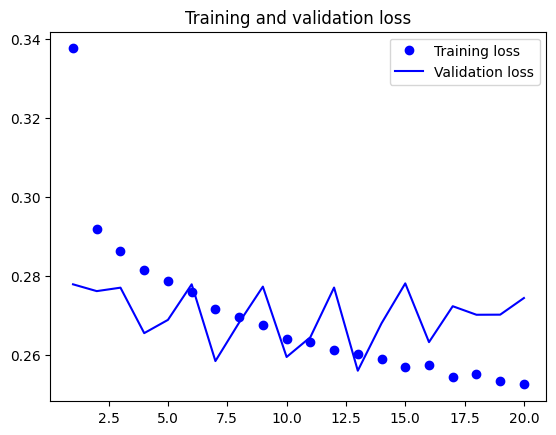

In [19]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Se **mantiene** el **MAE** de **0.26**.  

**Recien en 17 empieza el overfiting**.

El tiempo de entrenamiento no bajo, señal de que el cuello de botella esta en el uso recurrente de recursos y no en la falta de memoria.

### 32 y 16

Prueba estirando y luego redujendo la intensidad.

In [7]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    32,
    return_sequences=True,
    input_shape=(None, float_data.shape[-1])
))
model.add(GRU(
    16, 
    activation='relu',
))
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps
)

I0000 00:00:1765754626.869808 1868553 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11534 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1
/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1765754629.233768 1868912 cuda_dnn.cc:529] Loaded cuDNN version 90300


500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 262ms/step - loss: 0.3286 - val_loss: 0.2697
Epoch 2/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 264ms/step - loss: 0.2846 - val_loss: 0.2705
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 262ms/step - loss: 0.2745 - val_loss: 0.2773
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 263ms/step - loss: 0.2707 - val_loss: 0.2549
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 262ms/step - loss: 0.2676 - val_loss: 0.2546
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 263ms/step - loss: 0.2637 - val_loss: 0.2787
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 264ms/step - loss: 0.2618 - val_loss: 0.2593
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 262ms/step - loss: 0.2545 - val_loss: 0.2606
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 263ms/step - loss: 0.2510 - val_loss: 0.2822
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 261ms/step - loss: 0.2446 - val_loss: 0.2657
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 262ms/step - loss: 0.2403 - val_loss: 0.2784
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 262ms/step - loss: 0.2362 - val_loss: 0.2840
Epoch 13/20
500/50

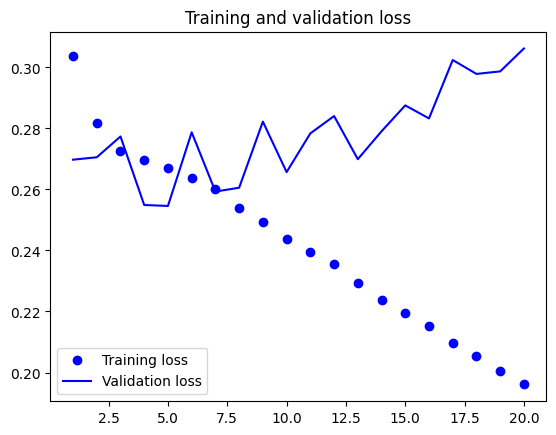

In [8]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Intvertir el crecimiento de los atributos no favorecio el algoritmo, mas aun, el ***overfitting* comenzo antes**.

### 32 y 64 + Dropout

Incrementar la complejidad respecto a (16, 32) incrementa el ya pronunciado *overfitting* pero con tecnicas de regularizacion podria retenerse lo mejor de ambos mundos, maximizando la capacidad de aprendizaje y penalizando el aprendizaje de patrones especificos a los datos de entrenamiento.

In [12]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    32, 
    return_sequences=True,
    dropout=0.2, 
    recurrent_dropout=0.2, 
    input_shape=(None, float_data.shape[-1]))
)
model.add(GRU(
    64, 
    dropout=0.2, 
    recurrent_dropout=0.2, 
    input_shape=(None, float_data.shape[-1]))
)
model.add(Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(
    train_gen, 
    epochs=15,
    validation_data=val_gen,
    validation_steps=val_steps)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 371s 736ms/step - loss: 0.3697 - val_loss: 0.2777
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 368s 736ms/step - loss: 0.3256 - val_loss: 0.2708
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 368s 735ms/step - loss: 0.3175 - val_loss: 0.2805
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 367s 735ms/step - loss: 0.3107 - val_loss: 0.2984
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 368s 736ms/step - loss: 0.3055 - val_loss: 0.2631
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 368s 737ms/step - loss: 0.3007 - val_loss: 0.2863
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 368s 737ms/step - loss: 0.2968 - val_loss: 0.2722
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 368s 736ms/step - loss: 0.2908 - val_loss: 0.2638
Epoch 9/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 368s 736ms/step - loss: 0.2916 - val_loss: 0.2767
Epoch 10/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 368s 737ms/step - loss: 0.2881 - val_loss: 0.2703
Epoch 11/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 368s 736ms/step - loss: 0.2847 - val_loss: 0.2735
Epoch 12

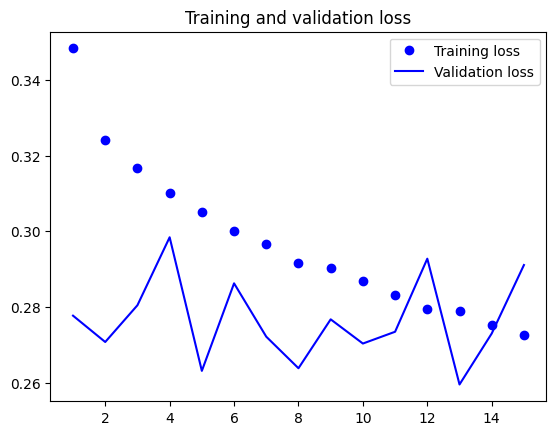

In [13]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

**No** hay ***overfitting***. **Tampoco mejora**, puede que la haya para mas epocas, pero la version con dropout tarda el doble por epoca por lo que no se intentara hacer mas experimentos con la misma.

Luego de hacer varias pruebas se considera que ninguna configuracion muestra una mejora ovia respecto a las demas

Para continuar se **elije** la **version *16y32*** que tubo **resultados por centecimas mejores** mientras esta en el **umbral inferior** de **tiempo de entrenamiento y de *overfitting***.

## Ajustar learning rate

De lo anterior se eligio *16y32* como la mejor configuracion de neuronas recurrentes.

Ahora se prueba decrementar el learning rate para ver si mejora la situacion de *overfitting* a la par que encuentra una mejor configuracion de pesos.

### Tasa de aprendizaje de 0.01

El valor default de learning rate es $0.001$, primero se hace una prueba incrementandolo a $0.01$. 

Se espera que esto acelere los sintomas de overfiting sin mostrar mejoras significativas en el rendimiento.

In [8]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    16,
    return_sequences=True,
    input_shape=(None, float_data.shape[-1])
))
model.add(GRU(
    32, 
    activation='relu',
))
model.add(Dense(1))

model.compile(
    optimizer=RMSprop(learning_rate=0.01), 
    loss='mae'
)

history = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    validation_steps=val_steps
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 261ms/step - loss: 0.3381 - val_loss: 0.2597
Epoch 2/15


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 261ms/step - loss: 0.2806 - val_loss: 0.2985
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 264ms/step - loss: 0.2637 - val_loss: 0.2896
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 260ms/step - loss: 0.2500 - val_loss: 0.2876
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 261ms/step - loss: 0.2341 - val_loss: 0.2835
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 261ms/step - loss: 0.2278 - val_loss: 0.3095
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 260ms/step - loss: 0.2197 - val_loss: 0.3042
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 261ms/step - loss: 0.2142 - val_loss: 0.3054
Epoch 9/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 262ms/step - loss: 0.2097 - val_loss: 0.3246
Epoch 10/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 261ms/step - loss: 0.2023 - val_loss: 0.3159
Epoch 11/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 262ms/step - loss: 0.1985 - val_loss: 0.3395
Epoch 12/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 260ms/step - loss: 0.1979 - val_loss: 0.3236
Epoch 13/15
500/50

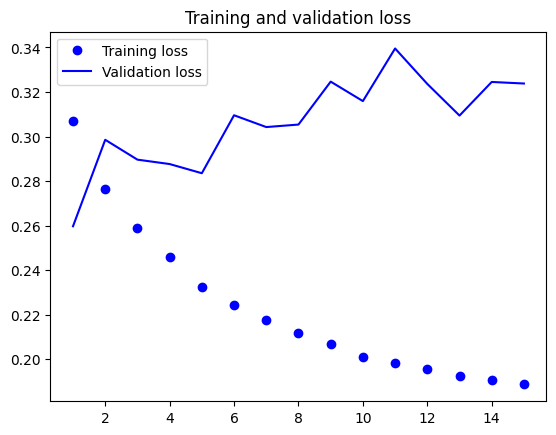

In [9]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Empezo con el mejor rendimiento (**0.26**) y el *overfiting* actuo desde la segunda epoca.

### Tasa de aprendizaje de 0.0001

Ahora se reduce la tasa de aprendizaje a $0.0001$. 

Se espera que esto redusca el overfitin y permita explorar a profundidad las configuraciones de pesos encontradas. 

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    16,
    return_sequences=True,
    input_shape=(None, float_data.shape[-1])
))
model.add(GRU(
    32, 
    activation='relu',
))
model.add(Dense(1))

model.compile(
    optimizer=RMSprop(learning_rate=0.0001), 
    loss='mae'
)

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps
)

I0000 00:00:1766868166.129868 1451311 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 111 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1
/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1766868168.352600 1451500 cuda_dnn.cc:529] Loaded cuDNN version 90300


500/500 ━━━━━━━━━━━━━━━━━━━━ 186s 368ms/step - loss: 0.6032 - val_loss: 0.3091
Epoch 2/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 246s 459ms/step - loss: 0.3337 - val_loss: 0.2942
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 200s 401ms/step - loss: 0.3146 - val_loss: 0.2968
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 197s 393ms/step - loss: 0.3090 - val_loss: 0.2775
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 238s 465ms/step - loss: 0.3006 - val_loss: 0.2799
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 174s 349ms/step - loss: 0.2987 - val_loss: 0.2889
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 199s 398ms/step - loss: 0.2957 - val_loss: 0.2742
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2915 - val_loss: 0.2731
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2920 - val_loss: 0.2853
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 279ms/step - loss: 0.2919 - val_loss: 0.2628
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 279ms/step - loss: 0.2881 - val_loss: 0.2745
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 277ms/step - loss: 0.2855 - val_loss: 0.2798
Epoch 13/20
500/50

In [ ]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Mejora constante sin *overifiting*, no obstante la tasa de aprendizaje tan pequeña proboca que el entrenamiento tarde mucho mas. 

Luego de 20 epocas (1hr) solo se llego a 0.27.

### Tasa de aprendizaje de 0.005

Ahora se prueba con un valor intermedio de $0.005$. 

Se espera que tarde, pero que se llegue a mostrar el mejor rendimiento.

In [6]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    16,
    return_sequences=True,
    input_shape=(None, float_data.shape[-1])
))
model.add(GRU(
    32, 
    activation='relu',
))
model.add(Dense(1))

model.compile(
    optimizer=RMSprop(learning_rate=0.0005), 
    loss='mae'
)

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    validation_steps=val_steps
)

I0000 00:00:1766959946.933075 1816429 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11534 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1
/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1766959949.176835 1816684 cuda_dnn.cc:529] Loaded cuDNN version 90300


500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 268ms/step - loss: 0.3992 - val_loss: 0.2766
Epoch 2/30


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 269ms/step - loss: 0.2958 - val_loss: 0.2775
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 268ms/step - loss: 0.2865 - val_loss: 0.2797
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 269ms/step - loss: 0.2808 - val_loss: 0.2624
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 135s 270ms/step - loss: 0.2781 - val_loss: 0.2613
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 135s 270ms/step - loss: 0.2744 - val_loss: 0.2761
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 135s 269ms/step - loss: 0.2720 - val_loss: 0.2614
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 268ms/step - loss: 0.2678 - val_loss: 0.2698
Epoch 9/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 268ms/step - loss: 0.2646 - val_loss: 0.2753
Epoch 10/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 135s 270ms/step - loss: 0.2652 - val_loss: 0.2562
Epoch 11/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 135s 269ms/step - loss: 0.2602 - val_loss: 0.2754
Epoch 12/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 269ms/step - loss: 0.2580 - val_loss: 0.2852
Epoch 13/30
500/50

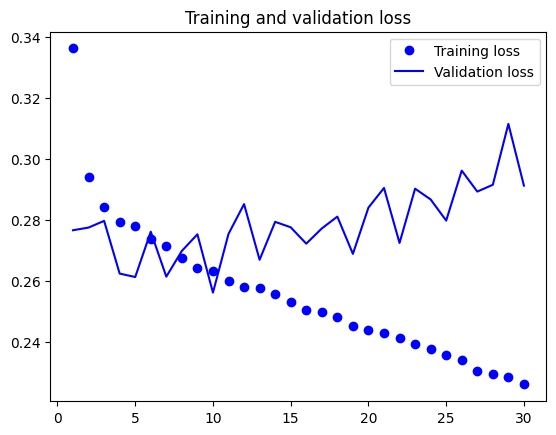

In [7]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

El mejor rendimiento es 0.26 (epoca 10) luego sobreentrena. 

En **general**, las **variaciones** en la **tasa de aprendizaje** **modificaron** que tan **rapido** se llega al ***overfiting***, **no** el **mejor resultado** que se alcanza.

## Dense para recodificar

Una capa|red densa que recodifique la informacion recibida antes de que esta sea procesada por la red recurrente puede favorecer el aprendizaje de patrones. 

Se parte de la solucion anterior y se le agregan **tres redes densas delante**.

In [8]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(None, float_data.shape[-1])))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(GRU(
    16,
    return_sequences=True,
))
model.add(GRU(
    32, 
    activation='relu',
))
model.add(Dense(1))

model.compile(
    optimizer=RMSprop(learning_rate=0.01), 
    loss='mae'
)

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 278ms/step - loss: 0.3878 - val_loss: 0.2874
Epoch 2/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2941 - val_loss: 0.3041
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2750 - val_loss: 0.3113
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 277ms/step - loss: 0.2566 - val_loss: 0.2927
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 276ms/step - loss: 0.2453 - val_loss: 0.3257
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 277ms/step - loss: 0.2333 - val_loss: 0.3136
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 280ms/step - loss: 0.2248 - val_loss: 0.3153
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 296ms/step - loss: 0.2212 - val_loss: 0.3178
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2176 - val_loss: 0.3190
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2127 - val_loss: 0.3256
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 279ms/step - loss: 0.2089 - val_loss: 0.3226
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2038 - val_loss: 0.3278
Epoch 13/20
500/50

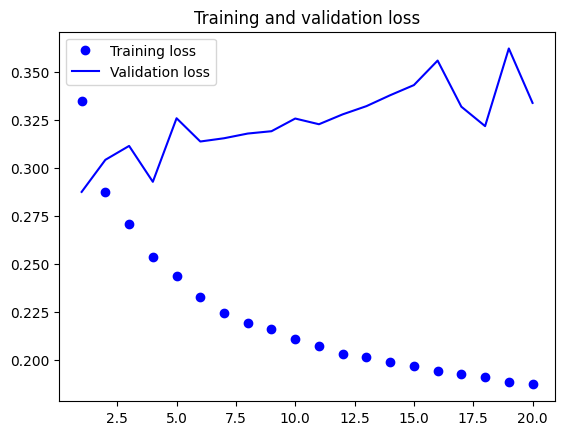

In [9]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Los resultados fueron peores, el **MAE** empeoro hasta **0.29** practicamente **igualando la linea base**. 

# Una lineal antes

Se prueba agregar **una capa lineal grande delante** de las capas recurrentes.

Se entrena durante mas epocas para confirmar limites del modelo.

In [10]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(Dense(1024, activation='relu', input_shape=(None, float_data.shape[-1])))
model.add(GRU(
    16,
    return_sequences=True,
))
model.add(GRU(
    32, 
    activation='relu',
))
model.add(Dense(1))

model.compile(
    optimizer=RMSprop(learning_rate=0.01), 
    loss='mae'
)

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 278ms/step - loss: 0.3890 - val_loss: 0.2993
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 277ms/step - loss: 0.2957 - val_loss: 0.3176
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2776 - val_loss: 0.3019
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2677 - val_loss: 0.3006
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 277ms/step - loss: 0.2594 - val_loss: 0.3131
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2551 - val_loss: 0.3155
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 276ms/step - loss: 0.2507 - val_loss: 0.2983
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 277ms/step - loss: 0.2459 - val_loss: 0.3220
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 277ms/step - loss: 0.2411 - val_loss: 0.3510
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 277ms/step - loss: 0.2350 - val_loss: 0.3309
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 277ms/step - loss: 0.2354 - val_loss: 0.3255
Epoch 12

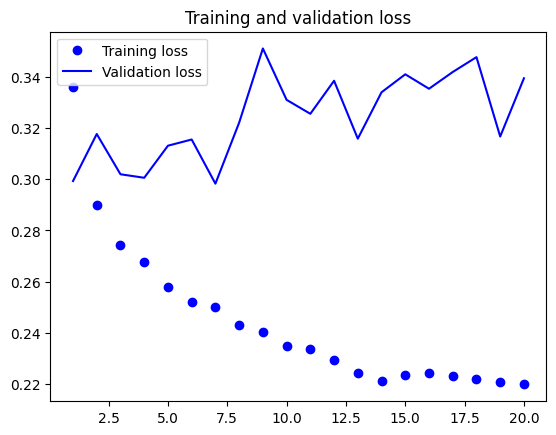

In [11]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Resultados **similar**es **a varias capas recurrentes**, el **MAE** empeora hasta **0.31**.

***Overfitting*** a partir de **epoca 4**.

### Lineal despues de las recurrentes

Se hace la prueba añadiendo 1 sola capa lineal grande depues de las capas recurrentes

In [9]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    16,
    return_sequences=True,
    input_shape=(None, float_data.shape[-1])
))
model.add(GRU(
    32, 
    activation='relu',
))
model.add(Dense(1024, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer=RMSprop(learning_rate=0.01), 
    loss='mae'
)

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps
)

Epoch 1/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1767555716.236714 1359382 cuda_dnn.cc:529] Loaded cuDNN version 90300


500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 276ms/step - loss: 0.4067 - val_loss: 0.2655
Epoch 2/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 275ms/step - loss: 0.3020 - val_loss: 0.2664
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 276ms/step - loss: 0.2809 - val_loss: 0.3034
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 276ms/step - loss: 0.2635 - val_loss: 0.2911
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 276ms/step - loss: 0.2504 - val_loss: 0.2890
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 277ms/step - loss: 0.2391 - val_loss: 0.3129
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 275ms/step - loss: 0.2321 - val_loss: 0.2926
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2239 - val_loss: 0.2946
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2168 - val_loss: 0.3151
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 277ms/step - loss: 0.2132 - val_loss: 0.2897
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2098 - val_loss: 0.3073
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - loss: 0.2048 - val_loss: 0.3294
Epoch 13/20
500/50

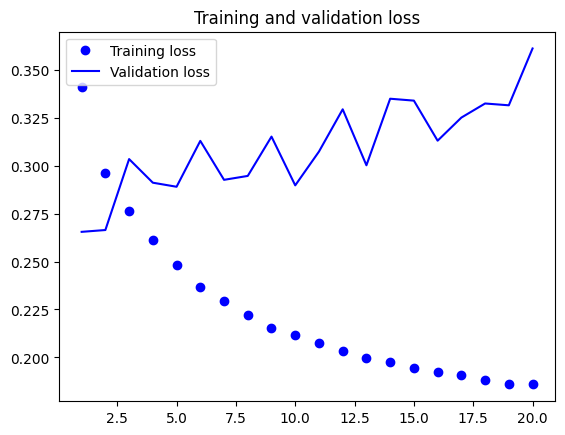

In [10]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

El **MAE** es **0.26** en el mejor momento.

***Overfitting*** a partir de la epoca 3

### Lineales despues de las recurrentes

Se distribuye la complejidad añadida a lo largo de 2 capas.

In [11]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.optimizers import RMSprop

model = Sequential()
model.add(GRU(
    16,
    return_sequences=True,
    input_shape=(None, float_data.shape[-1])
))
model.add(GRU(
    32, 
    activation='relu',
))
model.add(Dense(512, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer=RMSprop(learning_rate=0.01), 
    loss='mae'
)

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps
)

Epoch 1/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 135s 267ms/step - loss: 0.4139 - val_loss: 0.3271
Epoch 2/20


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 264ms/step - loss: 0.3014 - val_loss: 0.2988
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 265ms/step - loss: 0.2850 - val_loss: 0.2932
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 265ms/step - loss: 0.2685 - val_loss: 0.2826
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 265ms/step - loss: 0.2517 - val_loss: 0.2906
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 266ms/step - loss: 0.2384 - val_loss: 0.3178
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 266ms/step - loss: 0.2268 - val_loss: 0.2853
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 266ms/step - loss: 0.2231 - val_loss: 0.3195
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 267ms/step - loss: 0.2140 - val_loss: 0.3143
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 265ms/step - loss: 0.2115 - val_loss: 0.2999
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 265ms/step - loss: 0.2052 - val_loss: 0.3096
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 265ms/step - loss: 0.2023 - val_loss: 0.3152
Epoch 13/20
500/50

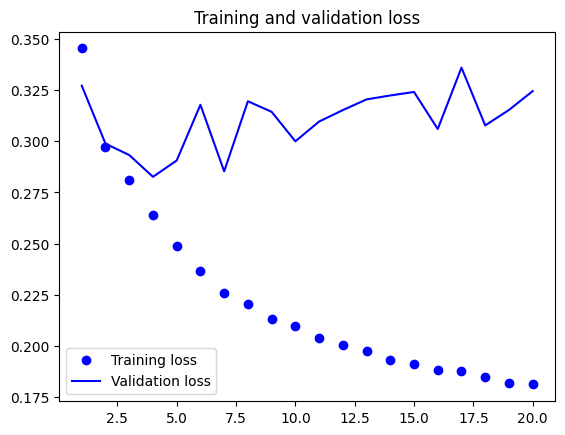

In [12]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Esta aproximacion no mejoró todos los resultados previos, alcanzando un **MAE** de **0.28**.

**Overfitting** a partir de la **epoca 3**.